In [5]:
%pip install -U -r requirements.txt

  Using cached aiohttp-3.11.11-cp310-cp310-macosx_10_9_x86_64.whl.metadata (7.7 kB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
from pipeline import Pipeline

pipeline = Pipeline()


DEBUG:pipeline: Creating Spark session...

DEBUG:pipeline: Spark session created.



In [7]:
import pandas as pd

In [8]:
reload = False

candles_file_name = "ohlcv1d"
candles_path = f"{pipeline.data_dir}/{candles_file_name}.csv"

if reload:
    candles_df = await pipeline.get_candles_df(timeframe="1d")  # noqa: PLE1142
    pipeline.save_csv(candles_file_name, candles_df)

candles_df = pipeline.spark.read.csv(candles_path, header=True, inferSchema=True)

In [9]:
from pyspark.sql import functions as F


def get_ticker_prices(ticker: str) -> pd.Series:
    prices = candles_df.filter(F.col("symbol") == ticker).toPandas().set_index("timestamp")["close"]
    prices.name = ticker
    return prices

BTC_price = get_ticker_prices("BTC")
ETH_price = get_ticker_prices("ETH")
SOL_price = get_ticker_prices("SOL")

In [10]:
import matplotlib.pyplot as plt


def plot_returns(Xs: list[pd.Series]) -> None:
    for X in Xs:
        X_return = X.pct_change()[1:]
        plt.hist(X_return, bins=20, label=X.name)

    plt.xlabel("Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


def plot_price(X: pd.Series, ticker: str) -> None:
    SMA7D = X.rolling(window=7).mean()
    SMA30D = X.rolling(window=30).mean()
    SMA90D = X.rolling(window=90).mean()

    plt.plot(X.index, X.values)
    plt.plot(SMA7D.index, SMA7D.values)
    plt.plot(SMA30D.index, SMA30D.values)
    plt.plot(SMA90D.index, SMA90D.values)

    plt.ylabel("Price")
    plt.legend([ticker, "7D SMA", "30D SMA", "90D SMA"])


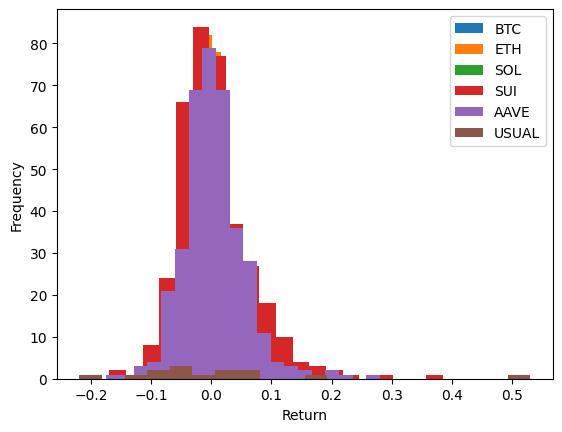

In [11]:
# tickers = candles_df.select("symbol").distinct().toPandas()["symbol"].tolist()
tickers = ["BTC", "ETH", "SOL", "SUI", "AAVE", "USUAL"]
prices = [get_ticker_prices(ticker) for ticker in tickers]

plot_returns(prices)
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller


def test_stationarity(timeseries: pd.Series, cutoff: float = 0.01) -> bool:
    pvalue = adfuller(timeseries)[1]
    if pvalue < cutoff:
        pipeline.logger.info("%s is likely stationary", timeseries.name)
        return True

    pipeline.logger.error("%s is likely not stationary", timeseries.name)
    return False

BTC_price = get_ticker_prices("BTC")
test_stationarity(BTC_price)

BTC_price_return = BTC_price.pct_change()[1:]
BTC_price_return.name = "BTC_price_return"
test_stationarity(BTC_price_return)


ERROR:pipeline: BTC is likely not stationary                           

INFO:pipeline: BTC_price_return is likely stationary



True

In [18]:
from statsmodels.tsa.stattools import coint

ETH_price = get_ticker_prices("ETH")
ETH_price_return = ETH_price.pct_change()[1:]
ETH_price_return.name = "ETH_price_return"
test_stationarity(ETH_price_return)

SOL_price = get_ticker_prices("SOL")
SOL_price_return = SOL_price.pct_change()[1:]
SOL_price_return.name = "SOL_price_return"
test_stationarity(SOL_price_return)

RLB_price = get_ticker_prices("RLB")
RLB_price_return = RLB_price.pct_change()[1:]
RLB_price_return.name = "RLB_price_return"
test_stationarity(RLB_price_return)

def test_cointegration(X: pd.Series, Y: pd.Series, cutoff: float = 0.01) -> bool:
    res = coint(X, Y)
    _, pvalue, _ = res
    if pvalue < cutoff:
        pipeline.logger.info("%s and %s are likely cointegrated", X.name, Y.name)
        pipeline.logger.debug("result: %s", res)
        return True

    pipeline.logger.error("%s and %s are likely not cointegrated", X.name, Y.name)
    return False

test_cointegration(BTC_price_return, ETH_price_return)
test_cointegration(BTC_price_return, SOL_price_return)
test_cointegration(ETH_price_return, SOL_price_return)
test_cointegration(RLB_price_return, SOL_price_return)





INFO:pipeline: ETH_price_return is likely stationary                   

INFO:pipeline: SOL_price_return is likely stationary

INFO:pipeline: RLB_price_return is likely stationary                   

INFO:pipeline: BTC_price_return and ETH_price_return are likely cointegrated

INFO:pipeline: BTC_price_return and SOL_price_return are likely cointegrated

INFO:pipeline: ETH_price_return and SOL_price_return are likely cointegrated

INFO:pipeline: RLB_price_return and SOL_price_return are likely cointegrated



True

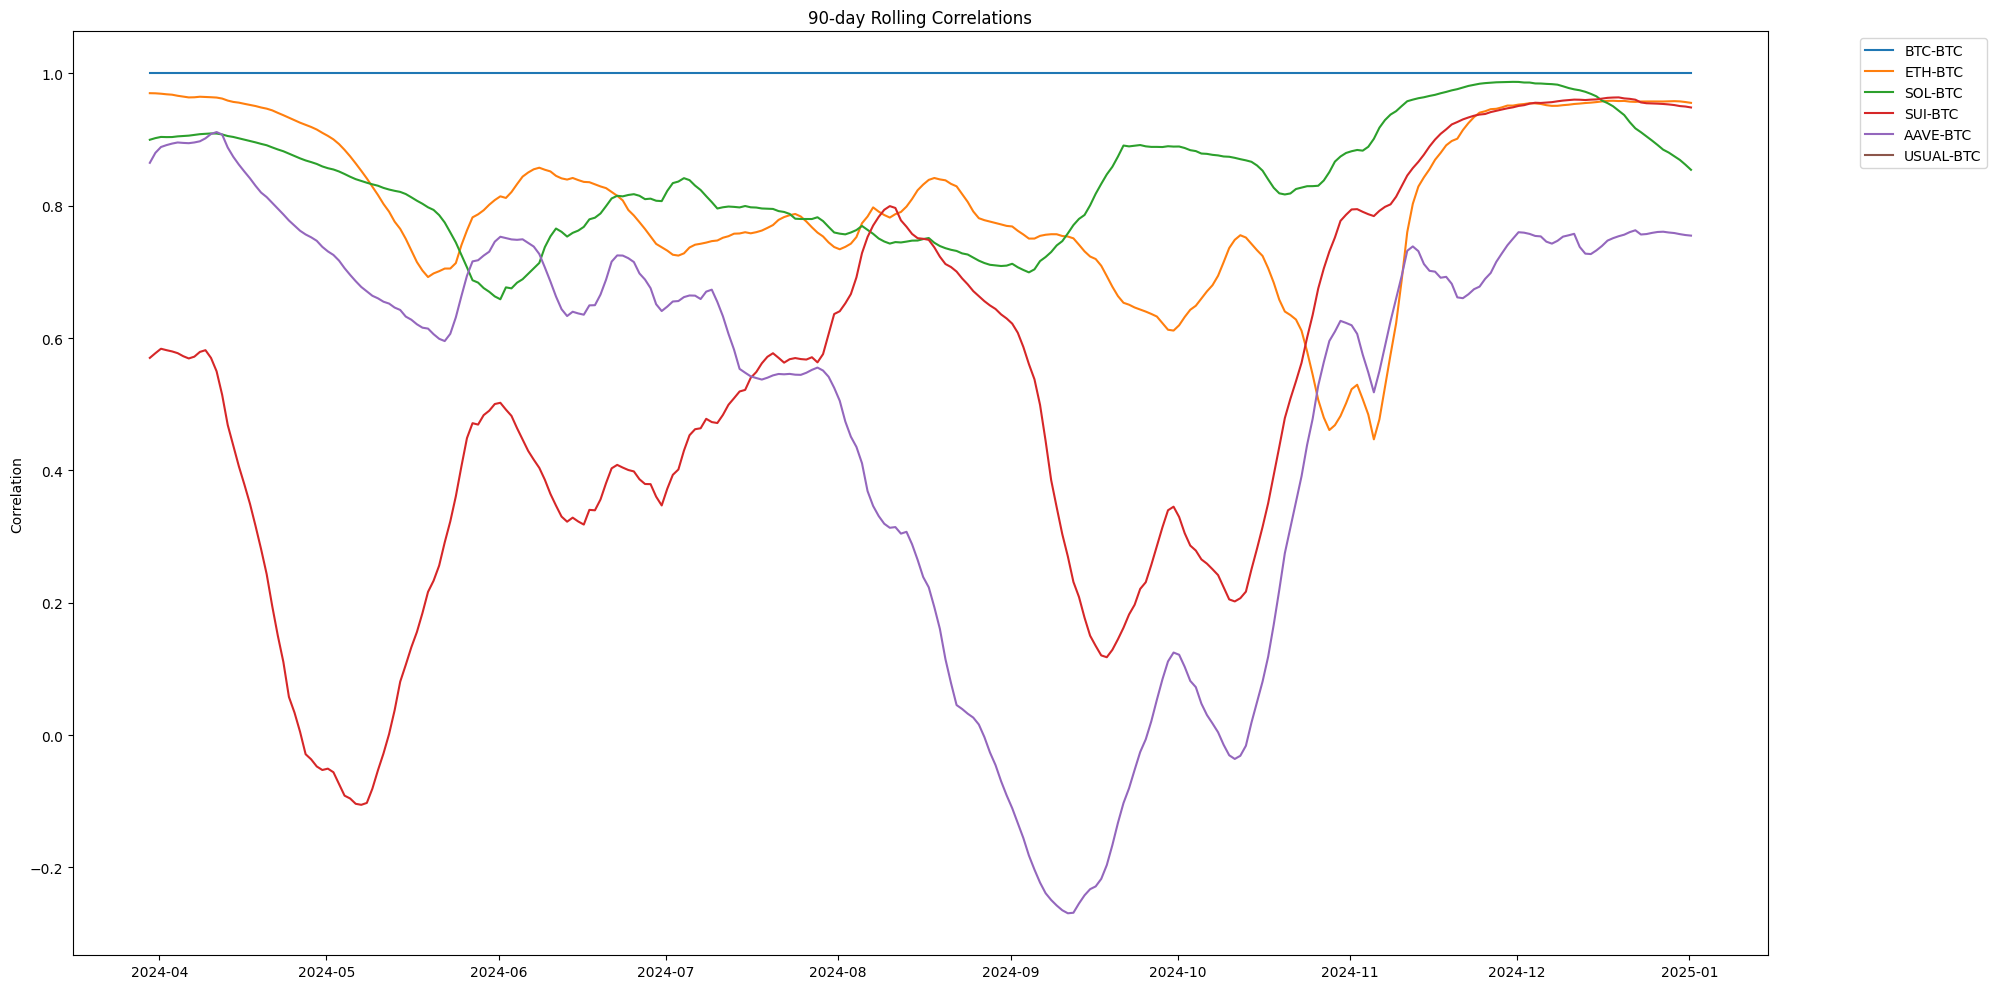

In [13]:

rolling_correlation_window = 90

# Calculate rolling correlations between all pairs of tickers
correlations = {}
for i, ticker1 in enumerate(tickers):
    price1 = prices[i]
    ticker2 = "BTC"
    price2 = prices[tickers.index(ticker2)]
    corr = price1.rolling(window=rolling_correlation_window).corr(price2)
    pair = f"{ticker1}-{ticker2}"
    correlations[pair] = corr

# Plot correlations
plt.figure(figsize=(20,10))
for pair, corr in correlations.items():
    plt.plot(corr.index, corr.values, label=pair)
plt.ylabel("Correlation")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title(f"{rolling_correlation_window}-day Rolling Correlations")
plt.tight_layout()
plt.show()
